In [82]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits import mplot3d


In [83]:
# create target data
x = np.arange(0, 20, 1)
y = x**2

# engineer features .
X_train = np.c_[x, x**2, x**3]   #<-- added engineered feature
y_train = y

In [84]:
def model(X, w, b):
    # y = np.dot(X, w) + b
    y = X @ w + b
    return y

In [85]:
def compute_cost(X, y, w, b): 
    # J function
    m = X.shape[0]
    e = y - model(X, w, b) # (w*x+b)
    total_cost = (1/(2* m)) * sum(e**2)
    return total_cost


In [86]:
b_init = 0
w_init = np.array([0.08, 0.54, 0.03]) # np.zeros(X_train.shape[1])

In [87]:
# Compute and display cost using our pre-chosen optimal parameters. 
cost = compute_cost(X_train, y_train, w_init, b_init)
print(f'Cost at optimal w : {cost}')

Cost at optimal w : 106.27298500000005


In [88]:
def compute_gradient(X, y, w, b): 
    # Number of training examples
    m = X.shape[0] 
    e = model(X, w, b)- y
    dw = (1/m) * X.T @ e
    # dw = (1/m) * np.dot(e, X)
    db = (1/m) * e
    dw = sum(dw)
    db = sum(db)
    return dw, db

In [89]:
from copy import deepcopy
def gradient_descent(x, y, w_in = 0, b_in = 0, alpha = 1, num_iters = 100):
    
    w = deepcopy(w_in)
    b = deepcopy(b_in)
    p_history = [(w, b)]
    cost_history  = [compute_cost(x, y, w, b)] # J
    
    for i in range(num_iters):
        dw, db = compute_gradient(x, y, w, b)
        w = w - alpha * dw
        b = b - alpha * db
        p_history.append((w, b))
        cost_history.append(compute_cost(x, y, w, b))
        if i%100 == 0:
            print(f"Iteration {i:4}: Cost {cost_history[-1]:0.2e} ",
                  f"dj_dw: {dw}, dj_db: {db}  ",
                  f"w: {w}, b:{b}")

    return w, b, p_history, cost_history


In [90]:
def zscore_normalize_features(X):
    m = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X-m) / sigma
    return X_norm


In [91]:
# initialize parameters
initial_w = np.zeros_like(w_init)
initial_b = 0
# some gradient descent settings
iterations = 10000
tmp_alpha = 1.0e-8
# run gradient descent
w_final, b_final, p_history, cost_history = gradient_descent(X_train ,y_train, initial_w, initial_b, tmp_alpha, iterations)
print(f"(w,b) found by gradient descent: ({w_final},{b_final})")


Iteration    0: Cost 1.18e+04  dj_dw: -486603.3, dj_db: -123.5   w: [0.00486603 0.00486603 0.00486603], b:1.235e-06
Iteration  100: Cost 3.39e+02  dj_dw: -58.917595000544, dj_db: -14.166119683451164   w: [0.05641641 0.05641641 0.05641641], b:2.697203153872086e-05
Iteration  200: Cost 3.39e+02  dj_dw: -0.0039541082634286795, dj_db: -14.152872909081385   w: [0.05642265 0.05642265 0.05642265], b:4.112630947575649e-05
Iteration  300: Cost 3.39e+02  dj_dw: 0.003179498292297467, dj_db: -14.152863316728137   w: [0.05642264 0.05642264 0.05642264], b:5.527917691684964e-05
Iteration  400: Cost 3.39e+02  dj_dw: 0.0031803604483684467, dj_db: -14.152855327214807   w: [0.05642264 0.05642264 0.05642264], b:6.943203619879764e-05
Iteration  500: Cost 3.39e+02  dj_dw: 0.003180358726012855, dj_db: -14.152847337900118   w: [0.05642264 0.05642264 0.05642264], b:8.358488749140811e-05
Iteration  600: Cost 3.39e+02  dj_dw: 0.0031803569918338326, dj_db: -14.152839348589936   w: [0.05642263 0.05642263 0.0564226

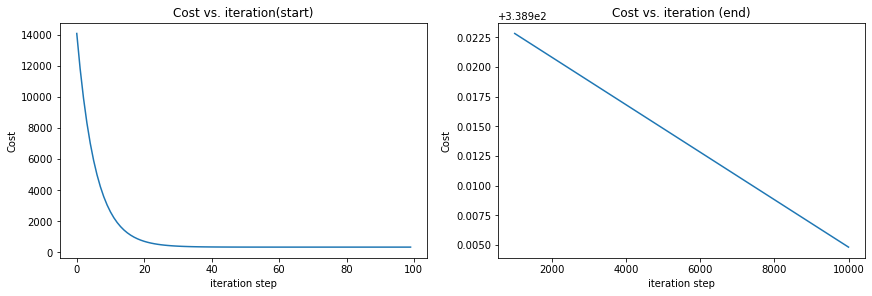

In [92]:
# plot cost versus iteration  
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12,4))
ax1.plot(cost_history[:100])
ax2.plot(1000 + np.arange(len(cost_history[1000:])), cost_history[1000:])
ax1.set_title("Cost vs. iteration(start)");  ax2.set_title("Cost vs. iteration (end)")
ax1.set_ylabel('Cost')            ;  ax2.set_ylabel('Cost') 
ax1.set_xlabel('iteration step')  ;  ax2.set_xlabel('iteration step') 
plt.show()

In [93]:
# nomalize
X_N_train = zscore_normalize_features(X_train)

# initialize parameters
initial_w = np.zeros_like(w_init)
initial_b = 0
# some gradient descent settings
iterations = 10000
tmp_alpha = 1.0e-1
# run gradient descent
w_final, b_final, p_history, cost_history = gradient_descent(X_N_train ,y_train, initial_w, initial_b, tmp_alpha, iterations)
print(f"(w,b) found by gradient descent: ({w_final},{b_final})")


Iteration    0: Cost 6.29e+03  dj_dw: -334.93768002778296, dj_db: -123.5   w: [33.493768 33.493768 33.493768], b:12.350000000000001
Iteration  100: Cost 1.25e+01  dj_dw: -2.7533531010703882e-14, dj_db: -0.003280332762615863   w: [38.38345625 38.38345625 38.38345625], b:123.49704770051365
Iteration  200: Cost 1.25e+01  dj_dw: -1.687538997430238e-14, dj_db: -8.71302175825539e-08   w: [38.38345625 38.38345625 38.38345625], b:123.4999999215828
Iteration  300: Cost 1.25e+01  dj_dw: -1.3100631690576847e-14, dj_db: -2.3006874183550963e-12   w: [38.38345625 38.38345625 38.38345625], b:123.49999999999793
Iteration  400: Cost 1.25e+01  dj_dw: -1.687538997430238e-14, dj_db: -5.6718518770537685e-14   w: [38.38345625 38.38345625 38.38345625], b:123.49999999999994
Iteration  500: Cost 1.25e+01  dj_dw: -1.687538997430238e-14, dj_db: -5.6718518770537685e-14   w: [38.38345625 38.38345625 38.38345625], b:123.49999999999994
Iteration  600: Cost 1.25e+01  dj_dw: -1.687538997430238e-14, dj_db: -5.671851877

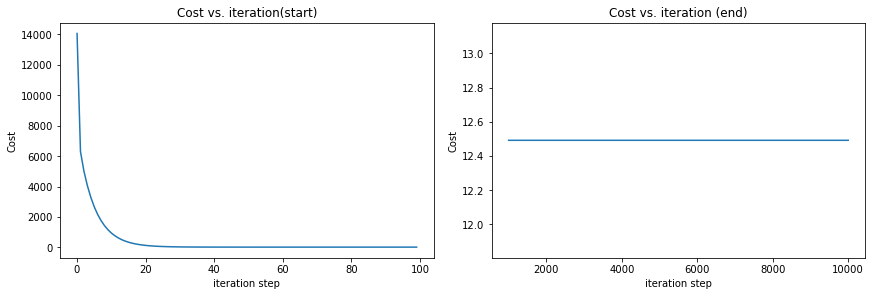

In [94]:
# plot cost versus iteration  
fig2, (ax3, ax4) = plt.subplots(1, 2, constrained_layout=True, figsize=(12,4))
ax3.plot(cost_history[:100])
ax4.plot(1000 + np.arange(len(cost_history[1000:])), cost_history[1000:])
ax3.set_title("Cost vs. iteration(start)");  ax4.set_title("Cost vs. iteration (end)")
ax3.set_ylabel('Cost')            ;  ax4.set_ylabel('Cost') 
ax3.set_xlabel('iteration step')  ;  ax4.set_xlabel('iteration step') 
plt.show()

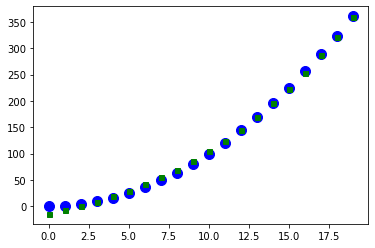

In [97]:
y_pred = model(X_N_train, w_final, b_final)
fig3, ax33 = plt.subplots()
ax33.plot(x, y, 'bo', markersize=10)
ax33.plot(x, y_pred, 'gs', markersize=5)
